<div style="background:darkgreen; width:100%; padding:40px;">
    <h2 style='text-align:center'>FYP- Heart Disease Prediction</h2>
    <p style='font-size:20px'>In this Final Year Project, we will build and train a machine‑learning model to predict whether a person is likely to have heart disease. We will use a public medical dataset containing features such as:
<li>Age 
<li>Resting Blood Pressure 
<li>Cholesterol Level 
<li>Chest‑Pain Type<br>
and more.....
</p>
</div>

<p style="background-color:green; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 1 | Import Libraries</p>

In [568]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns


from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score , classification_report , accuracy_score , f1_score , precision_score

# Models
from sklearn.naive_bayes import GaussianNB , BernoulliNB , MultinomialNB
from sklearn.tree import DecisionTreeClassifier , DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier ,RandomForestRegressor , AdaBoostRegressor
from xgboost import XGBClassifier , XGBRegressor
from sklearn.linear_model import LinearRegression ,LogisticRegression
from sklearn.neighbors import KNeighborsRegressor , KNeighborsClassifier
from sklearn.ensemble import GradientBoostingRegressor , GradientBoostingClassifier
from sklearn.svm import SVC , SVR
from xgboost import XGBClassifier , XGBRegressor

#grid search cv for cross validation
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV

from sklearn.preprocessing import QuantileTransformer , PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#pickle
import pickle
import warnings
warnings.filterwarnings('ignore')

<p style="background-color:green; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 2 | Load Datset 1</p>

In [570]:
df1 = pd.read_csv('heart_disease_uci.csv')
df1.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


<p style="background-color:green; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 3 | Preprocessing of datset 1</p>

### Data types

In [573]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


<div style="border-radius:0 10px 0 10px; background-color:#90EE90; color:black; padding:10px">
<h3>Observations</h3>
 <p>In dataset 1 (UCI Dataset) there are 8 numerical columns and 8 are categorical columns.</p>

</div>

### Missing Values and Duplicated

In [576]:
(df1.isnull().sum()/ len(df1)) * 100

id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
num          0.000000
dtype: float64

In [577]:
df1.duplicated().sum()

0

<div style="border-radius:0 10px 0 10px; background-color:#90EE90; color:black; padding:10px">
<h3>Observations</h3>
 <p>In dataset 1 (UCI Dataset) some columns have missing values.</p>
 <p>But in ca, thal have 50%+ missing values.</p>

</div>

### Summary by Column

In [580]:
## numerical
for col in df1.columns:
    
    if pd.api.types.is_numeric_dtype(df1[col]):
        print(f'\n---{col}---')
        describe = df1[col].describe()[['mean','50%','std','min','max']]
        describe.index = ['mean','median','std','min','max']
        print(describe.reset_index())


---id---
    index          id
0    mean  460.500000
1  median  460.500000
2     std  265.725422
3     min    1.000000
4     max  920.000000

---age---
    index        age
0    mean  53.510870
1  median  54.000000
2     std   9.424685
3     min  28.000000
4     max  77.000000

---trestbps---
    index    trestbps
0    mean  132.132404
1  median  130.000000
2     std   19.066070
3     min    0.000000
4     max  200.000000

---chol---
    index        chol
0    mean  199.130337
1  median  223.000000
2     std  110.780810
3     min    0.000000
4     max  603.000000

---thalch---
    index      thalch
0    mean  137.545665
1  median  140.000000
2     std   25.926276
3     min   60.000000
4     max  202.000000

---oldpeak---
    index   oldpeak
0    mean  0.878788
1  median  0.500000
2     std  1.091226
3     min -2.600000
4     max  6.200000

---ca---
    index        ca
0    mean  0.676375
1  median  0.000000
2     std  0.935653
3     min  0.000000
4     max  3.000000

---num---
    ind

<div style="border-radius:0 10px 0 10px; background-color:#90EE90; color:black; padding:10px">
<h3>Observations</h3>
 <p><b>1: Age</b> Column mean/average is approximatly 53 and the youngest person age is 28 while the oldest one is 77.</p>
 <p><b>2: trestbps</b> Column refers to resting blood presure, where minimum value is 0 (error in our data) and maximum is 200 (which is very high).</p>
 <p><b>3: chol</b> Column represent cholesterol, where minimum value is 0 (error in our data) and maximum is 603.</p>
 <p><b>4: thalch</b> Column represent maximum heart rate achieved during exercise, where minimum value is 60 and maximum is 202.</p>
 <p><b>5: oldpeak</b> Column represent refers to the ST segment depression induced by exercise relative to rest, where minimum value is -2 and maximum is 6</p>
 <p><b>6: ca</b> Column CA" usually refers to Coronary Artery, where minimum value is 0 and maximum value is 3.</p>
 <p><b>7: num</b> Column is the target column with 4 values (0,1,2,3,4)</p>
 
</div>

In [582]:
## categorical
for col in df1.columns:
    if pd.api.types.is_object_dtype(df1[col]):
        print(f'\n----{col}---')
        counts = df1[col].value_counts(dropna=False)
        example = df1.groupby(col).head(1)[col]
        print(counts.reset_index())
        print(f'\n')
        print(example.to_list())


----sex---
      sex  count
0    Male    726
1  Female    194


['Male', 'Female']

----dataset---
         dataset  count
0      Cleveland    304
1        Hungary    293
2  VA Long Beach    200
3    Switzerland    123


['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']

----cp---
                cp  count
0     asymptomatic    496
1      non-anginal    204
2  atypical angina    174
3   typical angina     46


['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']

----fbs---
     fbs  count
0  False    692
1   True    138
2    NaN     90


[True, False]

----restecg---
            restecg  count
0            normal    551
1    lv hypertrophy    188
2  st-t abnormality    179
3               NaN      2


['lv hypertrophy', 'normal', 'st-t abnormality']

----exang---
   exang  count
0  False    528
1   True    337
2    NaN     55


[False, True]

----slope---
         slope  count
0         flat    345
1          NaN    309
2    upsloping    203
3  downsloping     

<div style="border-radius:0 10px 0 10px; background-color:#90EE90; color:black; padding:10px">
<h3>Observations</h3>
 <p><b>1: sex</b> Column repesent gender of the patients, which show that 726 data are about male in our dataset 1 and only 194 female. (imbalance)</p>
 <p><b>2: cp</b> Column represent chest pain, Typical Angina: 1, Atypical Angina: 2, Non-Anginal Pain: 3, Asymptomatic: 4.</p>
 <p><b>3: fbs</b> Column represent fasting blood sugar, True: 1, False: 0</p>
 <p><b>4: restecg</b> Column represent resting electrocardiographic results, normal: 0, st-t abnormality: 1, 1v hypertrophy: 2.</p>
 <p><b>5: exang</b> Column represent exercise-induced angina, True: 1, False: 0</p>
 <p><b>6: slope</b> Column represent rate of change in the ST segment of an electrocardiogram (ECG) during a stress test, relative to changes in heart rate, 0: Upsloping, 1: Flat, 2: Downsloping</p>
 <p><b>7: thal</b> Column is represent Thalassemia, 0: Normal, 1: Fixed Defect, 2: Reversible Defect </p>
 
</div>

<p style="background-color:green; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 4 | EDA</p>

### Univariate Analysis<br><br> <p style='color: red'>Numerical Columns</p>

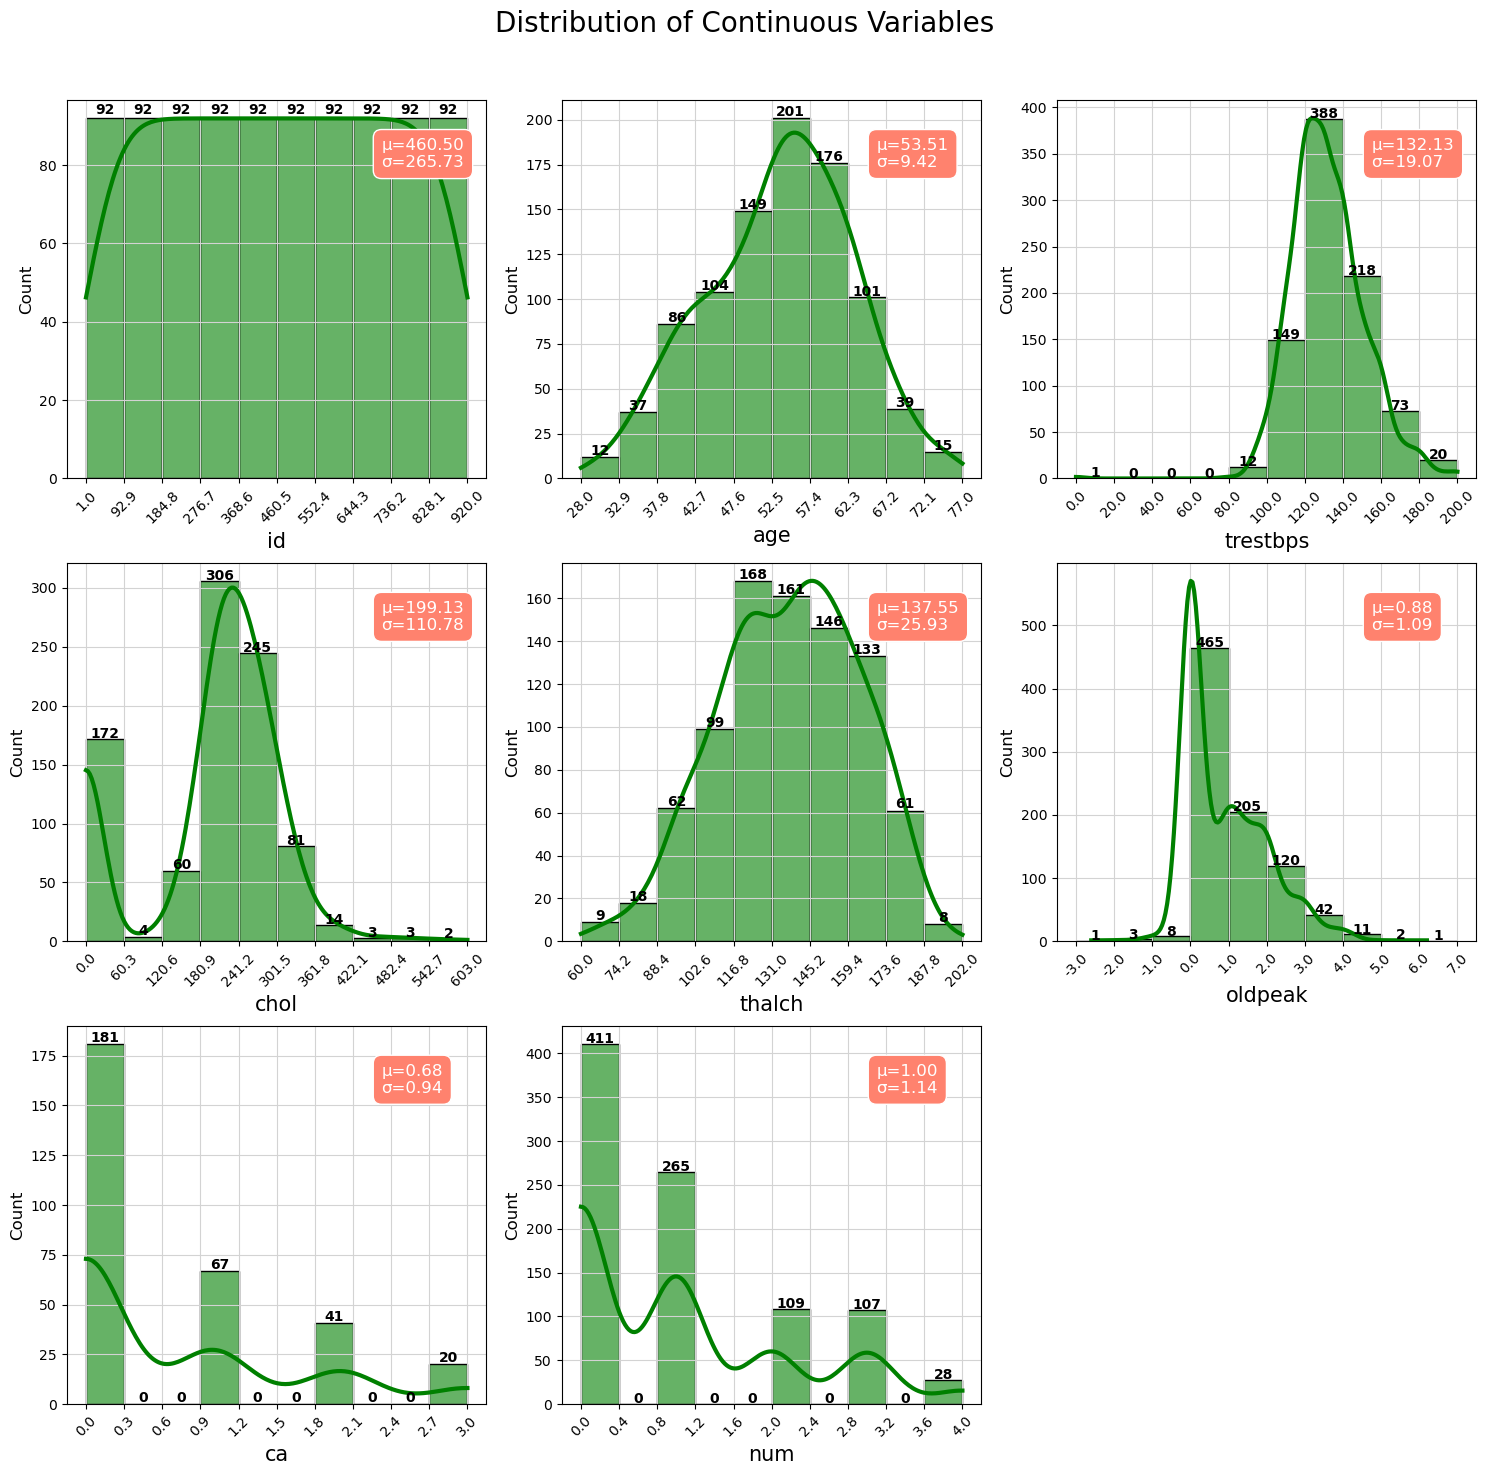

In [586]:
import math

num_cols = df1.select_dtypes(include='number')
n = len(num_cols.columns)

# 2. Setup subplots
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
axes = axes.flatten()

# 3. Loop through numeric columns
for ax, col in zip(axes, num_cols.columns):
    lo = np.floor(num_cols[col].min())
    hi = np.ceil (num_cols[col].max())
    _, bin_edges = np.histogram(num_cols[col], range=(lo, hi))

    g = sns.histplot(
        data=num_cols, x=col, bins=bin_edges, kde=True, ax=ax,
        color='green', alpha=0.6, line_kws={'lw':3}
    )

    ax.set_xlabel(col, fontsize=15)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_xticks(np.round(bin_edges,1))
    ax.set_xticklabels(ax.get_xticks(), rotation=45)
    ax.grid(color='lightgrey')

    for p in g.patches:
        h = p.get_height()
        ax.annotate(str(int(h)),
                    (p.get_x()+p.get_width()/2, h+1),
                    ha='center', fontsize=10, fontweight='bold')

    mu, sigma = num_cols[col].mean(), num_cols[col].std()
    ax.text(0.75, 0.9, f"μ={mu:.2f}\nσ={sigma:.2f}",
            transform=ax.transAxes, fontsize=12, va='top', color='white',
            bbox=dict(boxstyle='round', facecolor='#ff826e',
                      edgecolor='white', pad=0.5)
    )

# 4. Hide any extra axes
for extra_ax in axes[n:]:
    extra_ax.axis('off')

# 5. Title and layout
plt.suptitle('Distribution of Continuous Variables', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

<div style="border-radius:0 10px 0 10px; background-color:#90EE90; color:black; padding:10px">
<h3>Observations</h3>
 <p><b>Age Column</b> from graph we can clearly see that most patients are in range 52 to 62. fewer younger (<40) and older (>65)</p>
 <p><b>trestbps Column</b> Most people cluster between 120 and 140, a common normal-to-high range and a long tail toward higher pressures shows some with very high blood pressure.</p>
 <p><b>chol Column</b> Cholesterol ranges widely from 126 to over 500 mg/dL. most patient chol level lies between 180 to 300, but a few very high values pull the mean up.</p>
 <p><b>thalch Column</b> Ranges from 60 to about 202 bpm. Most are between 120 and 160 beats per minute. A roughly bell‑shaped curve suggests a fairly normal spread around the mean</p>
 <p><b>oldpeak Column</b> Most values lies between 0 to 3, and few values are >3 or <0</p>
 <p><b>ca Column</b>Most patients have 0 vessels (about 180 cases). Fewer have 1 or 2, and very few have 3.</p>
 <p><b>num Column</b>The frequency is highest at 0 (no disease) and small bump at 1 and fewer cases at levels 2–4.</p>
 

</div>

### Univariate Analysis<br><br> <p style='color: red'>Categorical Columns</p>

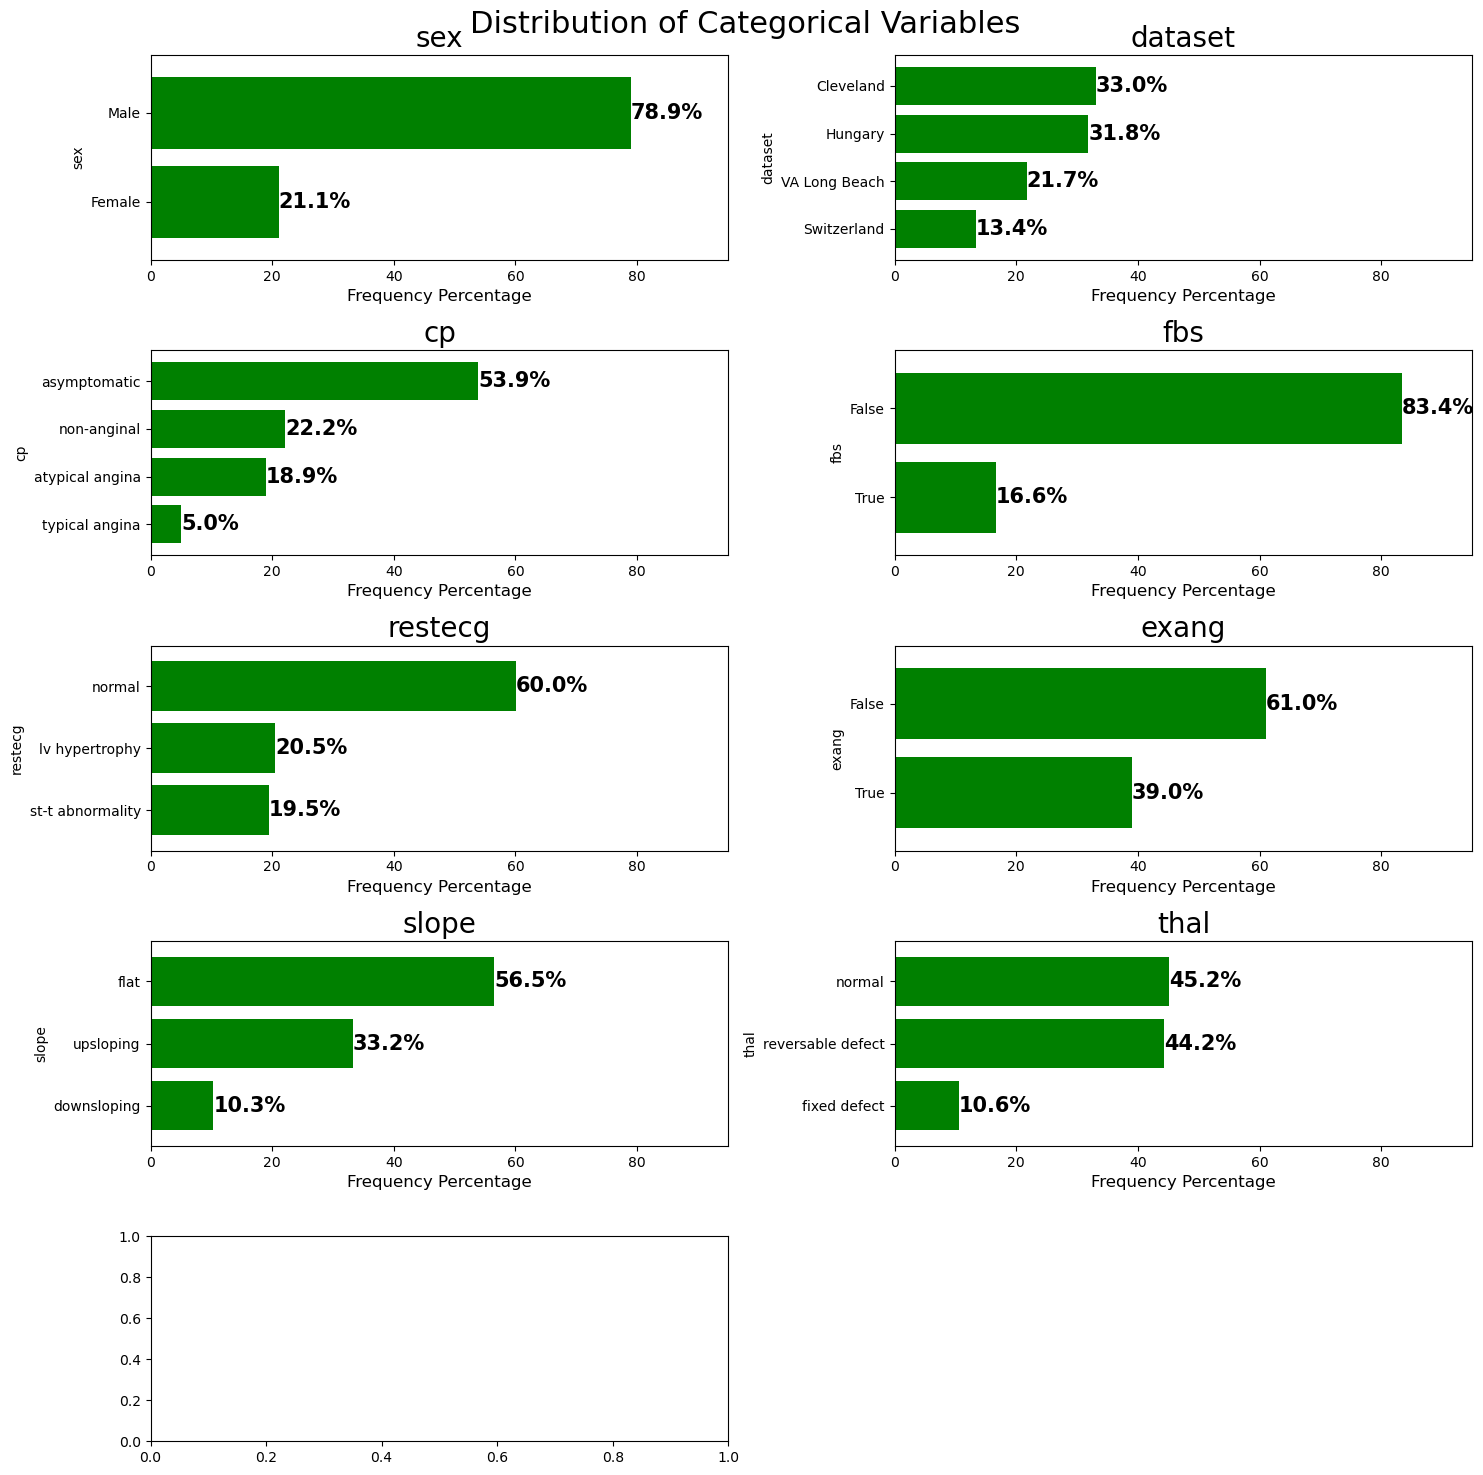

In [589]:
cat_cols = df1.select_dtypes(['object'])


fig, ax = plt.subplots(nrows=5, ncols=2, figsize=(15, 15))


for i, col in enumerate(cat_cols):
    row = i // 2
    col_idx = i % 2
    
    # Calculate frequency percentages
    value_counts = df1[col].value_counts(normalize=True).mul(100).sort_values()
    
    # Plot bar chart
    value_counts.plot(kind='barh', ax=ax[row, col_idx], width=0.8, color='green')
    
    # Add frequency percentages to the bars
    for index, value in enumerate(value_counts):
        ax[row, col_idx].text(value, index, str(round(value, 1)) + '%', fontsize=15, weight='bold', va='center')
    
    ax[row, col_idx].set_xlim([0, 95])
    ax[row, col_idx].set_xlabel('Frequency Percentage', fontsize=12)
    ax[row, col_idx].set_title(f'{col}', fontsize=20)

ax[4,1].axis('off')
plt.suptitle('Distribution of Categorical Variables', fontsize=22)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()
# plt.savefig('catBar.png')

<div style="border-radius:0 10px 0 10px; background-color:#90EE90; color:black; padding:10px">
<h3>Observations</h3>
 <p><b>Sex Column</b> <li>Male ≈ 79% <li>Female ≈ 21%. There are almost four times as many men as women in this dataset.</p>
 <p><b>cp Column</b> <li>Asymptomatic 54%: no typical chest pain, but may have other symptoms.
<li>Non‑anginal 22%: chest discomfort not caused by heart disease.
<li>Atypical angina 19%: chest pain that doesn’t fit the classic pattern.
<li>Typical angina 5%: classic chest‑pain pattern (least common here)..</p>
 <p><b>fbs Column</b><li>False 83%: most people did not have high fasting blood sugar.
<li>True 17%: a minority had elevated fasting sugar.</p>
 <p><b>restecg  Column</b> <li>Normal 60%: most ECGs looked normal.
<li>Left‑ventricular hypertrophy 20%: some showed thickening of heart muscle.
<li>ST‑T abnormality 20%: similar number showed electrical changes in heart.</p>
 <p><b>exang Column</b><li>False 61%: did not develop chest pain during exercise.
<li>True 39%: developed chest pain when active or exercising.</p>
     <p><b>slope Column</b><li>Flat 57%: most had a flat ST segment at peak exercise.
<li>Upsloping 33%: a rising ST segment (usually less worrisome).
<li>Downsloping 10%: a falling ST segment (often a stronger sign of heart disease).</p>
 <p><b>thal Column</b><li>Normal 45%: normal blood flow seen under stress.
<li>Reversible defect 44%: area of poor blood flow that improves at rest.
<li>Fixed defect 11%: area of poor blood flow that stays bad even at rest.
</p>
 

</div>

<p style="background-color:green; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 5 | Bivariate Analysis</p>

<div style="border-radius:0 10px 0 10px; background-color:#90EE90; color:black; padding:10px">
In this step we will analyze all features with target column (num).<br>
- First we will analyze numerical vs target column<br>
- Than caterogrical vs target column
 

</div>

## Numerical vs Target Column

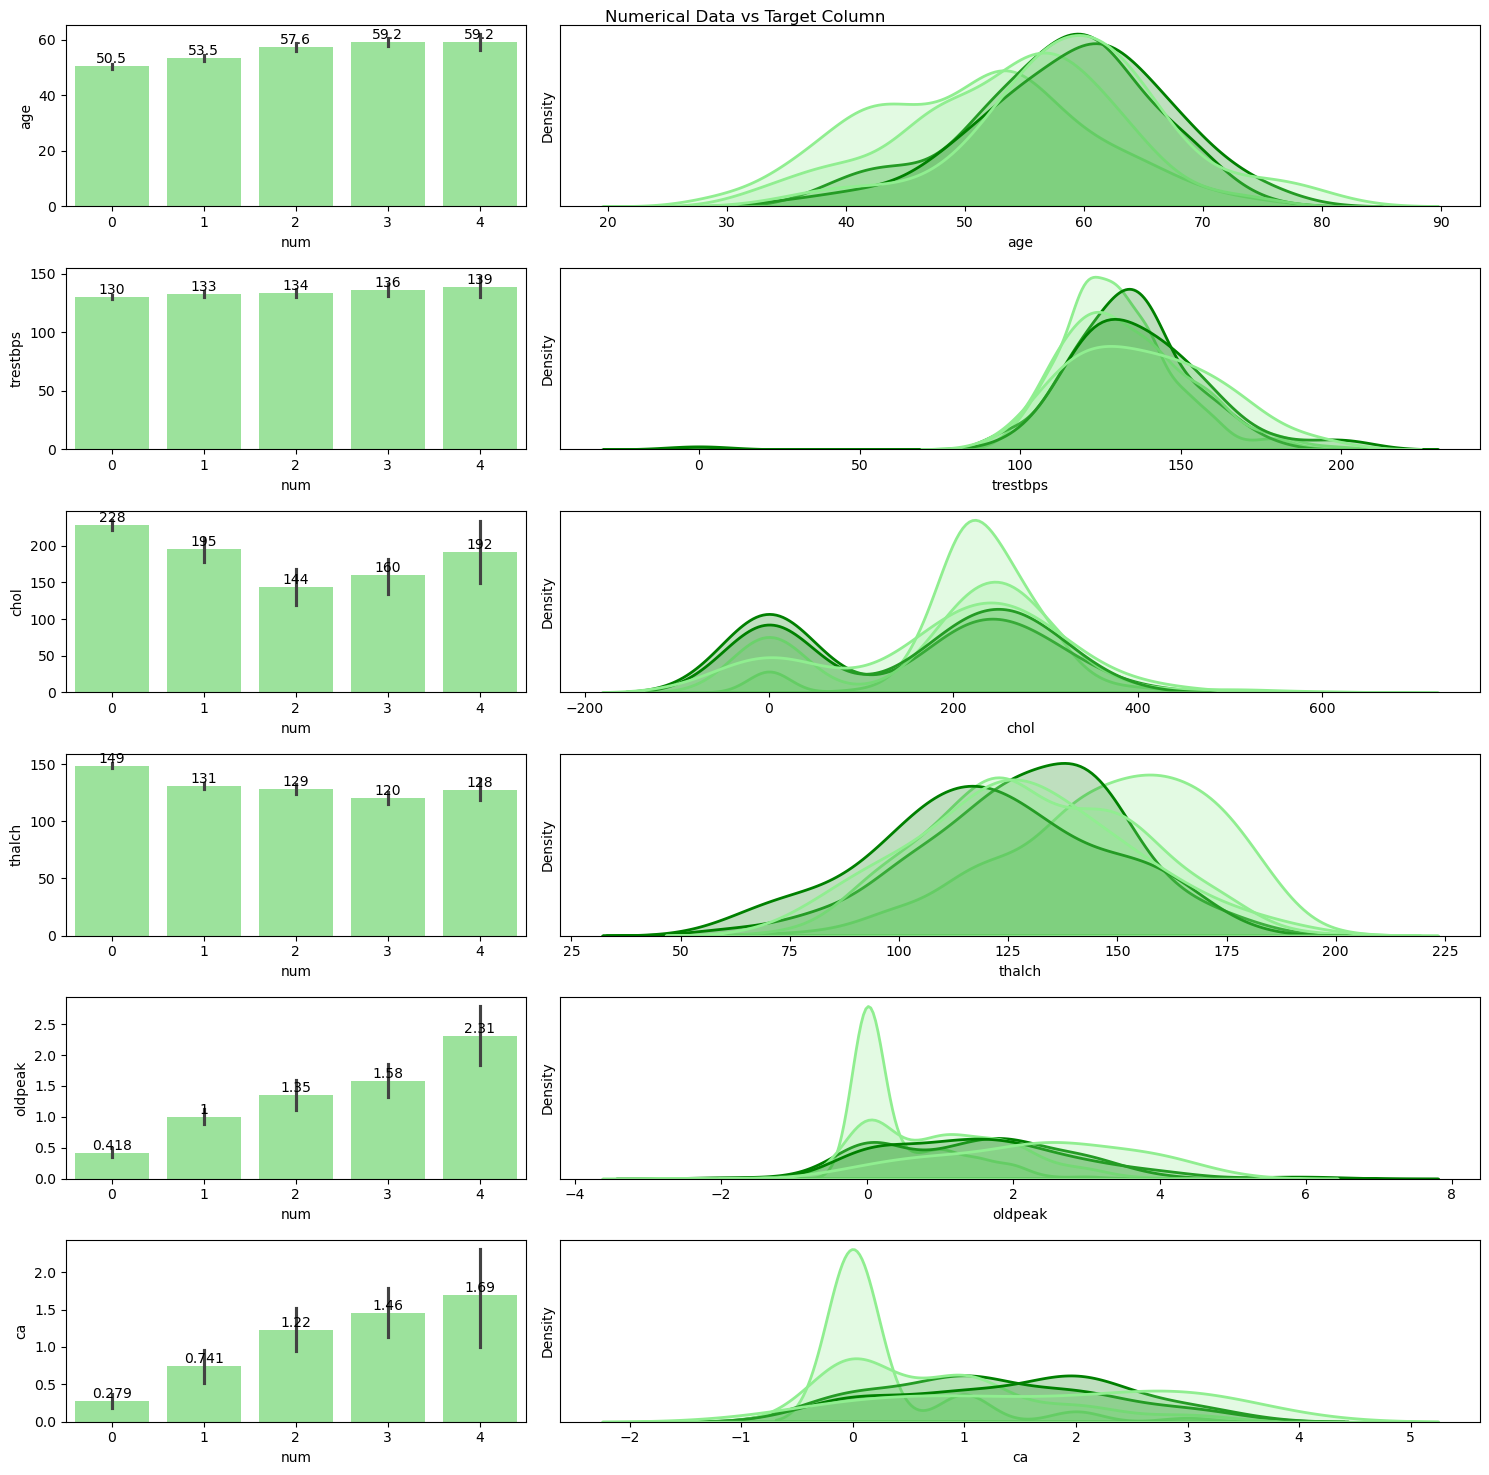

In [594]:
num_cols = ['age','trestbps','chol','thalch','oldpeak','ca']
sns.set_palette(['#90EE90', 'green'])

fig, ax = plt.subplots(len(num_cols), 2, figsize=(15,15), gridspec_kw={'width_ratios': [1,2]})

for i, col in enumerate(num_cols):
    graph = sns.barplot(data=df1, x='num', y=col, ax=ax[i,0])

    for label in df1['num'].unique():
        subset = df1[df1['num'] == label][col]
        if subset.nunique() > 1:  # Only plot if there's variance
            sns.kdeplot(data=subset, fill=True, linewidth=2, ax=ax[i,1], label=str(label))

    ax[i,1].set_yticks([])
    # ax[i,1].legend(title='Heart Disease', loc='upper right')

    for cont in graph.containers:
        graph.bar_label(cont, fmt='%.3g')



plt.suptitle('Numerical Data vs Target Column')
plt.tight_layout()
# plt.show()
plt.savefig('num v target.png')

<div style="border-radius:0 10px 0 10px; background-color:#90EE90; color:black; padding:10px">
<h3>Observations</h3>
 <h4>Age</h4>
<li>No disease (num=0): average age ~50.
<li>Severe disease (num=4): average age ~60.
<li>Interpretation: Older people in this data tend to have more heart problems.
<br><br>

<h4>Resting blood pressure</h4>
<li>num=0: ~130 mmHg
<li>num=4: ~140 mmHg
<li>Interpretation: Higher blood pressure at rest is slightly more common in people with heart disease.
<br><br>

<h4>Cholesterol</h4>
<li>It doesn’t just go up in a straight line—in fact, num=0 and num=4 both have relatively high averages, while mid-levels dip down.
<li>Interpretation: Cholesterol by itself isn’t a clear “the more, the worse” signal in this set.
<br><br>

<h4>Max heart rate (thalach) </h4>
<li>num=0: ~150 bpm
<li>num=4: ~128 bpm
<li>Interpretation: People with worse disease can’t push their heart rate as high during exercise.
<br><br>

<h4>ST depression (oldpeak)</h4>
<li>num=0: ~0.4 mm
<li>num=4: ~2.3 mm
<li>Interpretation: Bigger ST drops on ECG under stress mean more severe disease.
<br><br>

<h4>ca</h4>
<li>num=0: ~0.279 
<li>num=4: ~1.69
<li>Interpretation: Higher values of ca (more blocked vessels) are more common in people with heart disease.
<br><br>


</div>

## Categorical Features vs Target

In [597]:
df1.drop('dataset', axis=1,inplace=True)

In [598]:
cat_features = df1.select_dtypes('object')
cat_features.sample(2)

,sex,cp,fbs,restecg,exang,slope,thal
641,Male,asymptomatic,NaN,normal,False,flat,reversable defect
541,Male,asymptomatic,False,normal,False,NaN,NaN


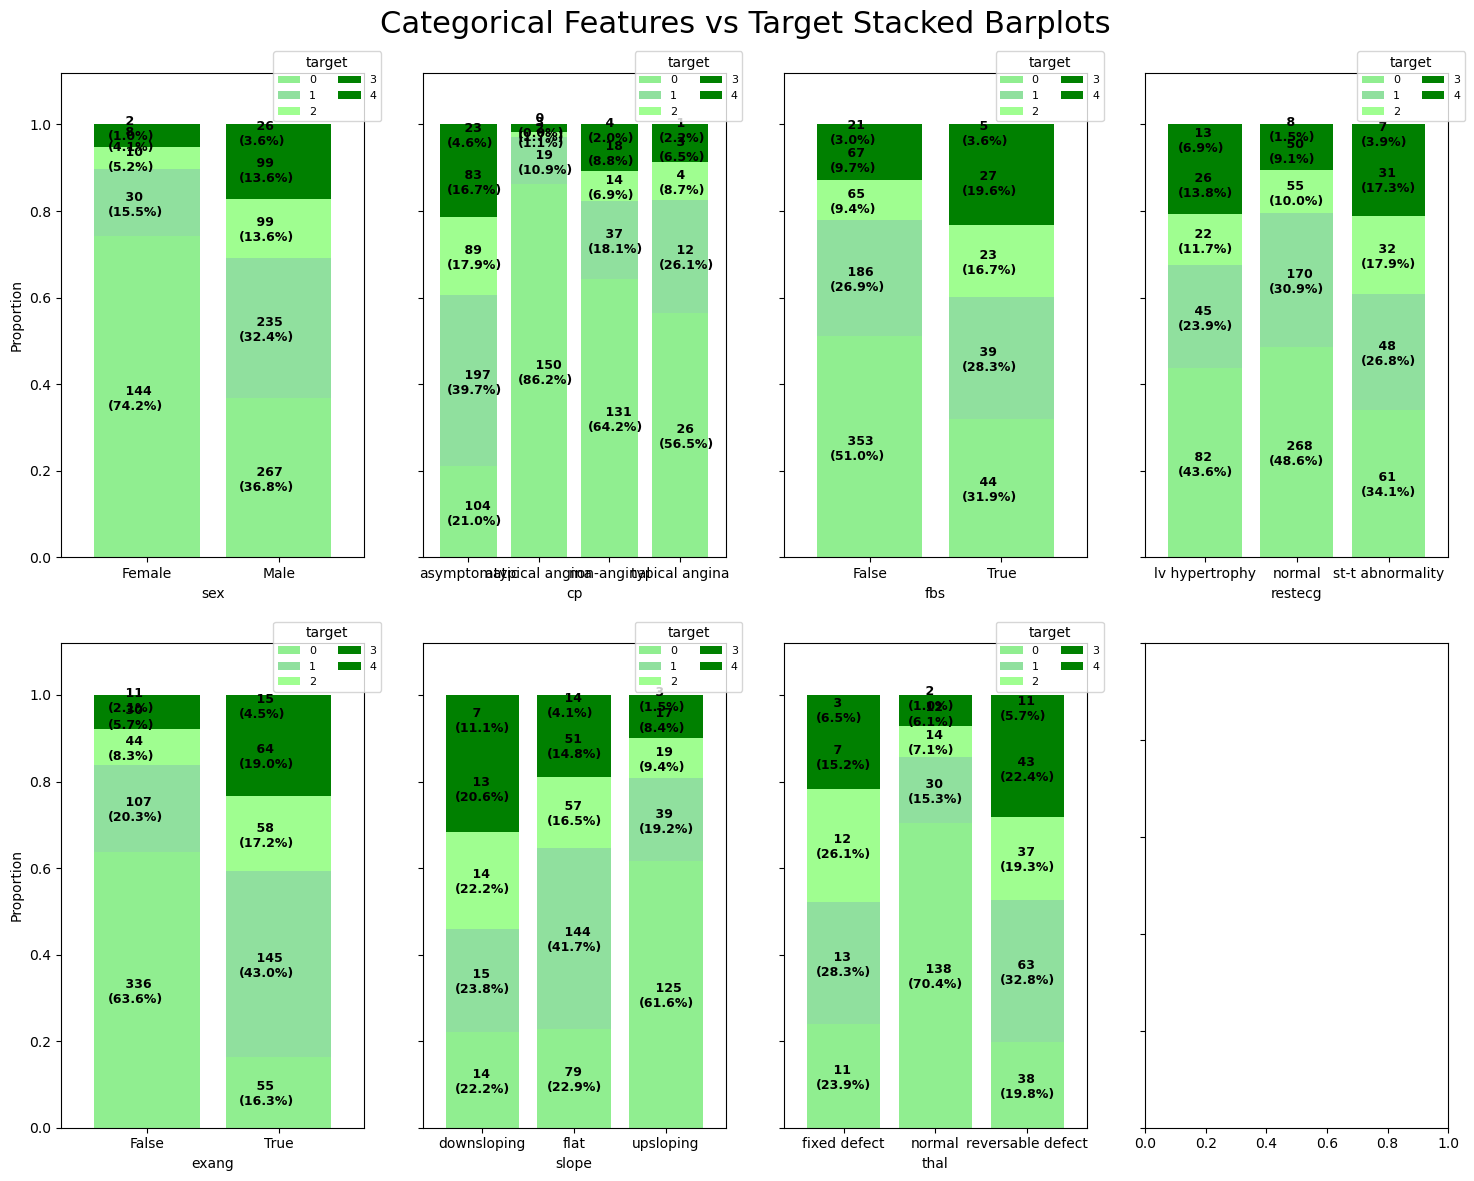

In [599]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(15,12))

for i,col in enumerate(cat_features):
    
   
    cross_tab = pd.crosstab(index=df1[col], columns=df1['num'])
    
    
    cross_tab_prop = pd.crosstab(index=df1[col], columns=df1['num'], normalize='index')

    
    cmp = ListedColormap(['#90EE90', '#90E09E','#9ffE90','green'])
    
    
    x, y = i//4, i%4
    cross_tab_prop.plot(kind='bar', ax=ax[x,y], stacked=True, width=0.8, colormap=cmp,
                        legend=False, ylabel='Proportion', sharey=True)
    
    
    for idx, val in enumerate([*cross_tab.index.values]):
        for (proportion, count, y_location) in zip(cross_tab_prop.loc[val],cross_tab.loc[val],cross_tab_prop.loc[val].cumsum()):
            ax[x,y].text(x=idx-0.3, y=(y_location-proportion)+(proportion/2)-0.03,
                         s = f'    {count}\n({np.round(proportion * 100, 1)}%)', 
                         color = "black", fontsize=9, fontweight="bold")
    
    # Add legend
    ax[x,y].legend(title='target', loc=(0.7,0.9), fontsize=8, ncol=2)
    # Set y limit
    ax[x,y].set_ylim([0,1.12])
    # Rotate xticks
    ax[x,y].set_xticklabels(ax[x,y].get_xticklabels(), rotation=0)
    
            
plt.suptitle('Categorical Features vs Target Stacked Barplots', fontsize=22)
plt.tight_layout()                     
plt.show()
# plt.savefig('cat vs target.png')

<div style="border-radius:0 10px 0 10px; background-color:#90EE90; color:black; padding:10px">
<h3>Observations</h3>
 <h4>Sex</h4>
<li>Female: A very large majority of females fall into target category 0 (74.2%).
<li>Male: Males have a much lower proportion in target category 0 (36.8%) and significantly higher proportions in target categories 1 (32.4%), 2            (13.6%), and 4 (13.6%) compared to females.
<li>Interpretation: Being male is associated with a much higher likelihood of having a target value greater than 0, suggesting a higher risk profile         compared to females in this dataset.
<br><br>

<h4>cp (chest pain)</h4>
<li>asymptomatic: This group has a relatively high proportion of individuals across all target levels, with a significant number in both target 0          (39.7%) and target 1 (36.2%).
<li>atypical angina: This is the lowest-risk group, with the vast majority (86.2%) having a target value of 0.
<li>non-anginal pain: This group has a high proportion of target 0 (64.2%), but still a notable percentage in target 1 (26.1%).
<li>typical angina: This group has a majority in target 0 (56.5%), with a notable portion in target 1 (26.1%).
<li>Interpretation: atypical angina is strongly associated with the lowest risk (target 0). asymptomatic chest pain, paradoxically, is associated with a higher and more distributed risk profile across the target levels.
<br><br>

<h4>fbs</h4>
<li>False (fbs <= 120): About 51% are in target 0, with 26.9% in target 1.
<li>True (fbs > 120): The distribution of True' group, with 31.9% in target 0 and 28.3% in target 1.
<li>Interpretation:  True shows a distinctly higher proportion of disease (targets 1–4) compared with fbs = False.
<br><br>

<h4>restecg (Resting Electrocardiographic Results) </h4>
<li>lv hypertrophy (left ventricular hypertrophy): This group has a lower proportion of target 0 (43.6%) and a higher proportion of target 1 (23.9%) compared to 'normal'.
<li>normal: This is the lowest-risk group, with 48.0% in target 0.
<li>st-t abnormality: This group appears to have the highest risk, with the lowest proportion of target 0 (34.1%) and the highest combined proportions for target values 1 through 4.
<li>Interpretation:  A 'normal' resting ECG is associated with the lowest risk. An 'st-t abnormality' is associated with the highest risk profile among the three categories.
<br><br>

<h4>exang (Exercise Induced Angina)</h4>
<li>False (no exang): A majority of this group is in target 0 (63.6%).
<li>True (has exang): This group has a dramatically different and higher-risk profile. Only 22.9% are in target 0, while a very large proportion falls into target 1 (43.0%) and target 2 (17.2%).
<li>Interpretation:The presence of exercise-induced angina is a strong indicator of a higher-risk target value.
<br><br>

<h4>slope (Slope of the Peak Exercise ST Segment) </h4>
<li>downsloping: This group has a high-risk profile, with a very low proportion in target 0 (22.2%) and high proportions in target 1 (23.8%) and target 2 (22.2%).
<li>flat: This group also indicates high risk, with only 22.9% in target 0 and the largest proportion of any subgroup in target 1 (41.7%).
<li>upsloping: This group is overwhelmingly low-risk, with 61.6% of individuals in target 0.
<li>Interpretation: Downsloping ST segments exhibit the highest disease rates; upsloping segments the lowest, with flat falling in between.
<br><br>

<h4>thal (Thalassemia)</h4>
<li>fixed defect: This group shows a high-risk profile, with only 23.9% in target 0 and a significant distribution across higher target values, especially target 1 (28.3%) and target 2 (26.1%).
<li>normal: This group is predominantly low-risk, with 70.4% in target 0.
<li>reversible defect: This is the highest-risk group. It has the lowest proportion in target 0 (19.8%) and very high proportions in target 1 (32.8%), target 2 (19.3%), and target 4 (5.7%).

</div>

<p style="background-color:green; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 6 | Data Preprocessing</p>

## 6.1 Removing Irrelevant Features

<div style="border-radius:0 10px 0 10px; background-color:#90EE90; color:black; padding:10px">
From the EDA, I did not notice there is any irrelevant feature.
But there was a feature called dataset which include places from where patient data was collected and I already remove it.
</div>

## 6.2 Missing Values

In [605]:
print('Missing Values in Categorical Features:\n',df1.select_dtypes('object').isna().sum())
print('\n================================================================================\n')
print('Missing Values in Numerical Features:\n',df1.select_dtypes(['int64','float64']).isna().sum())

Missing Values in Categorical Features:
 sex          0
cp           0
fbs         90
restecg      2
exang       55
slope      309
thal       486
dtype: int64


Missing Values in Numerical Features:
 id            0
age           0
trestbps     59
chol         30
thalch       55
oldpeak      62
ca          611
num           0
dtype: int64


In [606]:
categorical_cols = ['thal', 'ca', 'slope', 'exang', 'restecg','fbs', 'cp', 'sex', 'num']
bool_cols = ['fbs', 'exang']
numeric_cols = ['oldpeak', 'thalch', 'chol', 'trestbps', 'age']

<div style="border-radius:0 10px 0 10px; background-color:#90EE90; color:black; padding:10px">
I will use Random forest classifier, random forest regression and iterative imputer for imputation. 
</div>

## 6.2.1 Function to impute categorical values

In [609]:
missing_data_cols = df1.isnull().sum()[df1.isnull().sum() > 0].index.tolist()
missing_data_cols

['trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalch',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

In [610]:
def impute_categorical_values(pass_col):
    df_null = df1[df1[pass_col].isnull()]
    df_not_null = df1[df1[pass_col].notnull()]

    X = df_not_null.drop(pass_col, axis=1)
    y = df_not_null[pass_col]

    other_missing_cols = [col for col in missing_data_cols if col != pass_col]

    labelencoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = labelencoder.fit_transform(X[col])

    if pass_col in bool_cols:
        y = labelencoder.fit_transform(y)

        
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_classifier = RandomForestClassifier()

    rf_classifier.fit(X_train, y_train)

    y_pred = rf_classifier.predict(X_test)

    acc_score = accuracy_score(y_test, y_pred)

    print("The feature '"+ pass_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")


    X = df_null.drop(pass_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = labelencoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
                
    if len(df_null) > 0: 
        df_null[pass_col] = rf_classifier.predict(X)
        if pass_col in bool_cols:
            df_null[pass_col] = df_null[pass_col].map({0: False, 1: True})
        else:
            pass
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])
    
    return df_combined[pass_col]
    


In [611]:
for col in missing_data_cols:
    print("Missing Values", col, ":", str(round((df1[col].isnull().sum() / len(df1)) * 100, 2))+"%")
    if col in categorical_cols:
        df1[col] = impute_categorical_values(col)
    else:
        pass

Missing Values trestbps : 6.41%
Missing Values chol : 3.26%
Missing Values fbs : 9.78%
The feature 'fbs' has been imputed with 79.52 accuracy

Missing Values restecg : 0.22%
The feature 'restecg' has been imputed with 63.04 accuracy

Missing Values thalch : 5.98%
Missing Values exang : 5.98%
The feature 'exang' has been imputed with 80.35 accuracy

Missing Values oldpeak : 6.74%
Missing Values slope : 33.59%
The feature 'slope' has been imputed with 65.04 accuracy

Missing Values ca : 66.41%
The feature 'ca' has been imputed with 66.13 accuracy

Missing Values thal : 52.83%
The feature 'thal' has been imputed with 74.71 accuracy



In [612]:
df1.select_dtypes('object').isnull().sum()

sex        0
cp         0
fbs        0
restecg    0
exang      0
slope      0
thal       0
dtype: int64

## 6.2.2 Function to Impute Continuous Features

In [614]:
def impute_continuous_missing_data(df, passed_col, missing_data_cols):
    """
    Imputes missing values in a continuous column using a RandomForestRegressor.

    Args:
        df (pd.DataFrame): The DataFrame with missing data.
        passed_col (str): The name of the column with missing values to be imputed.
        missing_data_cols (list): A list of all columns that have missing data.

    Returns:
        pd.Series: The column with missing values imputed.
    """
    df_with_target = df[df[passed_col].notnull()].copy()
    df_to_impute = df[df[passed_col].isnull()].copy()

    if df_to_impute.empty:
        return df[passed_col]

    X_train_full = df_with_target.drop(columns=passed_col)
    y_train_full = df_with_target[passed_col]

    X_to_predict = df_to_impute.drop(columns=passed_col)

    # Identify categorical columns for encoding
    categorical_cols = [col for col in X_train_full.columns if X_train_full[col].dtype == 'object' or X_train_full[col].dtype.name == 'category']

    # Apply Label Encoding
    if categorical_cols:
        label_encoder = LabelEncoder()
        for col in categorical_cols:
            combined_col = pd.concat([X_train_full[col], X_to_predict[col]], axis=0).astype(str)
            label_encoder.fit(combined_col)
            X_train_full[col] = label_encoder.transform(X_train_full[col].astype(str))
            if not X_to_predict.empty:
                X_to_predict[col] = label_encoder.transform(X_to_predict[col].astype(str))

    # Impute other missing columns if any
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    if other_missing_cols:
        # We will not add the indicator to simplify assignment back to the dataframe
        iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=False)
        for col in other_missing_cols:
            if X_train_full[col].isnull().sum() > 0:
                # Reshape to 2D array for the imputer and reshape back to 1D for assignment
                imputed_values = iterative_imputer.fit_transform(X_train_full[[col]])
                X_train_full[col] = imputed_values.ravel()
            if not X_to_predict.empty and X_to_predict[col].isnull().sum() > 0:
                imputed_values = iterative_imputer.transform(X_to_predict[[col]])
                X_to_predict[col] = imputed_values.ravel()

    # Train the regressor on the fully cleaned training data
    rf_regressor = RandomForestRegressor(random_state=42)
    rf_regressor.fit(X_train_full, y_train_full)

    # Optional: Evaluate the model
    X_train, X_test, y_train, y_test = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)
    rf_regressor_eval = RandomForestRegressor(random_state=42)
    rf_regressor_eval.fit(X_train, y_train)
    y_pred = rf_regressor_eval.predict(X_test)
    print(f"Metrics for imputing '{passed_col}':")
    print(f"MAE = {mean_absolute_error(y_test, y_pred):.4f}")
    print(f"RMSE = {mean_squared_error(y_test, y_pred, squared=False):.4f}")
    print(f"R2 = {r2_score(y_test, y_pred):.4f}\n")


    # Predict and fill missing values
    if not X_to_predict.empty:
        predicted_values = rf_regressor.predict(X_to_predict)
        df_imputed = df.copy()
        df_imputed.loc[df_imputed[passed_col].isnull(), passed_col] = predicted_values
        return df_imputed[passed_col]
    else:
        return df[passed_col]

In [615]:
df1.isnull().sum()[df1.isnull().sum() > 0].sort_values(ascending=False)

oldpeak     62
trestbps    59
thalch      55
chol        30
dtype: int64

In [616]:
for col in numeric_cols:
    if df1[col].isnull().sum() > 0:
        df1[col] = impute_continuous_missing_data(df1, col, missing_data_cols)


Metrics for imputing 'oldpeak':
MAE = 0.6229
RMSE = 0.8404
R2 = 0.3271

Metrics for imputing 'thalch':
MAE = 16.5310
RMSE = 20.7338
R2 = 0.3749

Metrics for imputing 'chol':
MAE = 45.9030
RMSE = 64.9349
R2 = 0.6660

Metrics for imputing 'trestbps':
MAE = 13.4982
RMSE = 17.4010
R2 = 0.0546



In [617]:

df1.isnull().sum()

id          0
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

<div style="border-radius:0 10px 0 10px; background-color:#90EE90; color:black; padding:10px">
Here we are Done With Imputing Missing Values , By using Advance Methods Like Random Forest and Iterative Imputer . Which Are More Accurate then using 
Mean , Median or Mode We Define a Function for Imputing Missing Values.
</div>

## 6.3 Handling Outliers

## 6.3.1 Numeric Features

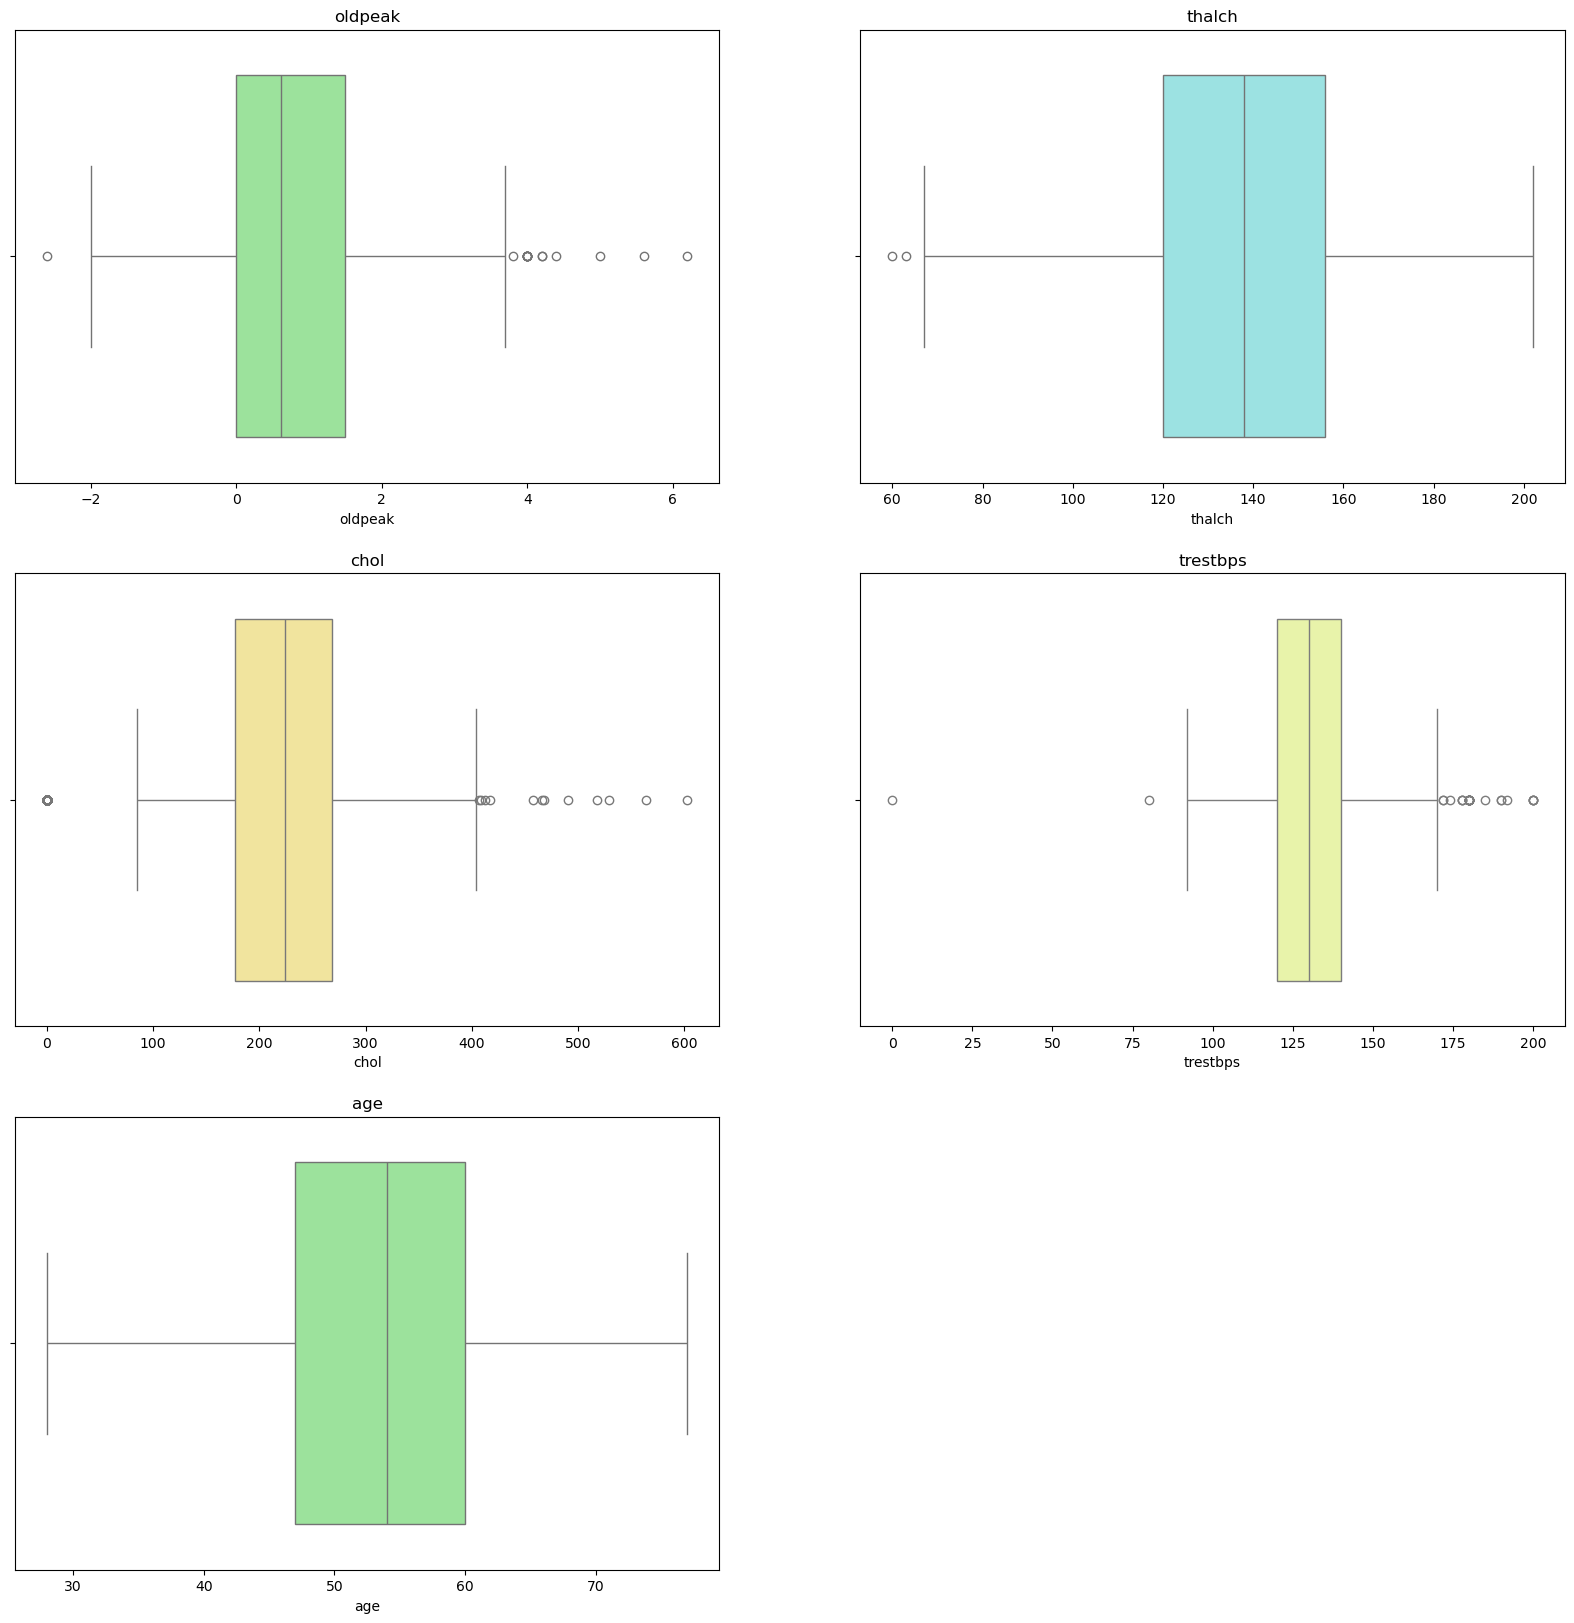

In [621]:
plt.figure(figsize=(20,20))
colors = ['#90EE90', '#90EEEE', '#FFEE90', '#F0FF9E']
for i,col in enumerate(numeric_cols):
    plt.subplot(3,2,1+i)
    c = colors[i % len(colors)]   
    sns.boxplot(x=df1[col], color=c)
    plt.title(col)
    
plt.show()
# plt.savefig('outliers_numeric_cols.png')

<div style="border-radius:0 10px 0 10px; background-color:#90EE90; color:black; padding:10px">
<h3>Observations</h3>
 <h4>oldpeak</h4>
<li>Whiskers extend from about –2 up to +4, meaning most values fall there.
<li> Several outliers above +4 (up to +6) and one low outlier near –2. These extreme ST changes may be rare cases or data errors.
<br><br>

<h4>thalch</h4>
<li>Whiskers go from ~60 bpm up to ~200 bpm.
<li>Few or no clear outliers—the range is wide but fairly continuous, suggesting a healthy spread of exercise capacities.

<br><br>

<h4>chol</h4>
<li>Whiskers extend roughly 120 to 420, but multiple outliers past 420 (up to ~600 mg/dl).
<li>Those high-end outliers may represent extreme cholesterol levels—worth , data error or or very high-risk patients.

<br><br>

<h4>trestbps</h4>
<li>Whiskers from about 80 up to 160.
<li>A couple of low outliers near 0–50 mm Hg, which are physiologically impossible—probably missing/incorrect data that slipped through..


<br><br>

<h4>Age</h4>
<li>Whiskers go from 29 up to 77—a reasonable adult age range.
<li>No extreme outliers, so the age data is clean and well-distributed.
<br><br>



<h2>Note: From the boxplots there is only one outlier (in trestbps column) other may have some meaning so I will remove only trestbps outli</h2>


</div>

In [623]:
df1[df1['trestbps'] == 0].reset_index()

,index,id,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,753,754,55,Male,non-anginal,0.0,0.0,False,normal,155.0,False,1.5,flat,0.0,reversable defect,3


In [624]:
df1 = df1[df1['trestbps'] != 0]
df1[df1['trestbps'] == 0].reset_index()

,index,id,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num


### Saving the clean Dataset

In [626]:
df1.to_csv('Clean_dataset.csv',index=False)

## 6.4 Conversion Categorical Features to Numerical 

### 6.4.1 Target Feature

<Axes: xlabel='num', ylabel='Count'>

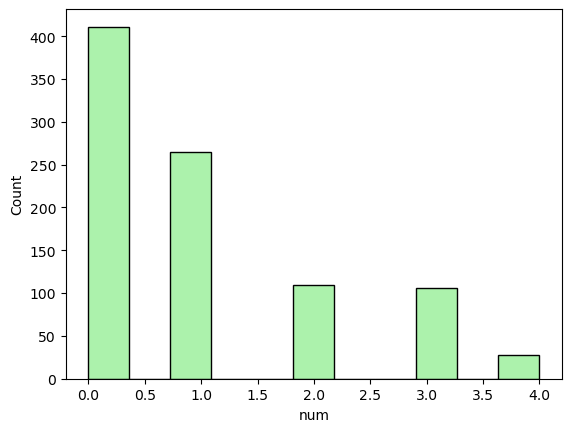

In [629]:
sns.histplot(x=df1['num'])

<div style="border-radius:0 10px 0 10px; background-color:#90EE90; color:black; padding:10px">

<p>The target column (num) is imbalanced, so I’m going to combine classes 1, 2, and 3 into a single class labeled 1</p>
</div>

In [631]:
df1.head(2)

,id,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2


### 6.4.2 Renaming

In [633]:
df1['thal'].replace({'fixed defect':'fixed_defect' , 'reversable defect': 'reversable_defect' }, inplace =True)
df1['cp'].replace({'typical angina':'typical_angina', 'atypical angina': 'atypical_angina' }, inplace =True)
df1['restecg'].replace({'normal': 'normal' , 'st-t abnormality': 'ST-T_wave_abnormality' , 'lv hypertrophy': 'left_ventricular_hypertrophy' }, inplace =True)

### 6.4.3 Droppng Irrelevant Columns

In [635]:
data_1 = df1[['age','sex','cp', 'trestbps', 'chol', 'fbs','restecg' , 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']].copy()

### 6.4.4 Renaming Columns

In [637]:
data_1.columns = ['age', 'sex', 'chest_pain_type' ,'resting_blood_pressure', 
              'cholesterol', 'fasting_blood_sugar','Restecg',
              'max_heart_rate_achieved', 'exercise_induced_angina', 
              'st_depression', 'st_slope_type', 'num_major_vessels', 
              'thalassemia_type', 'num']

### 6.4.4 Encoding SEX, FBS and EXANG Columns

In [639]:
data_1.head(2)

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,Restecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope_type,num_major_vessels,thalassemia_type,num
0,63,Male,typical_angina,145.0,233.0,True,left_ventricular_hypertrophy,150.0,False,2.3,downsloping,0.0,fixed_defect,0
1,67,Male,asymptomatic,160.0,286.0,False,left_ventricular_hypertrophy,108.0,True,1.5,flat,3.0,normal,2


In [640]:
data_1['sex'] = (df1['sex'] == 'Male')*1
data_1['fasting_blood_sugar'] = (df1['fbs'])*1
data_1['exercise_induced_angina'] = (df1['exang'])*1

In [641]:
data_1.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,Restecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope_type,num_major_vessels,thalassemia_type,num
0,63,1,typical_angina,145.0,233.0,1,left_ventricular_hypertrophy,150.0,0,2.3,downsloping,0.0,fixed_defect,0
1,67,1,asymptomatic,160.0,286.0,0,left_ventricular_hypertrophy,108.0,1,1.5,flat,3.0,normal,2
2,67,1,asymptomatic,120.0,229.0,0,left_ventricular_hypertrophy,129.0,1,2.6,flat,2.0,reversable_defect,1
3,37,1,non-anginal,130.0,250.0,0,normal,187.0,0,3.5,downsloping,0.0,normal,0
4,41,0,atypical_angina,130.0,204.0,0,left_ventricular_hypertrophy,172.0,0,1.4,upsloping,0.0,normal,0


In [686]:
data_1.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,Restecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope_type,num_major_vessels,thalassemia_type,num
0,63,1,typical_angina,145.0,233.0,1,left_ventricular_hypertrophy,150.0,0,2.3,downsloping,0.0,fixed_defect,0
1,67,1,asymptomatic,160.0,286.0,0,left_ventricular_hypertrophy,108.0,1,1.5,flat,3.0,normal,2
2,67,1,asymptomatic,120.0,229.0,0,left_ventricular_hypertrophy,129.0,1,2.6,flat,2.0,reversable_defect,1
3,37,1,non-anginal,130.0,250.0,0,normal,187.0,0,3.5,downsloping,0.0,normal,0
4,41,0,atypical_angina,130.0,204.0,0,left_ventricular_hypertrophy,172.0,0,1.4,upsloping,0.0,normal,0


<p style="background-color:green; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 7 | First Model Training (Random Forest Classifier)</p>

In [691]:
def train_random_forest(data, target):
    # Dictionary to store LabelEncoders for each categorical column
    label_encoders = {}

    # split the data into X and y
    X = data.drop(target, axis=1)
    y = data[target]

    # Create a new LabelEncoder for each categorical column
    for col in X.select_dtypes(include=['object', 'category']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        label_encoders[col] = le

    # split the data into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

    # Scaling Data
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Define the Random Forest model
    rf_model = RandomForestClassifier(random_state=0,class_weight='balanced')

    # Define hyperparameters for tuning
    param_grid = {
        'n_estimators': [50, 100, 150],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    # Perform GridSearchCV for hyperparameter tuning
    grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    # Get the best model and parameters
    best_rf_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    # Print the best hyperparameters
    print('Best Hyperparameters:')
    print(best_params)

    # Train the model on the full training set
    best_rf_model.fit(X_train, y_train)

    # Evaluate the model on the test set
    y_pred = best_rf_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f'Accuracy on Test Set: {accuracy:.2f}')

    # Inverse transform at the End
    # Loop through each column to decode the data
    for col, le in label_encoders.items():
        # Use the inverse_transform method to decode the column in both training and test sets
        X[col] = le.inverse_transform(X[col])

    return best_rf_model, best_params, accuracy

In [693]:
train_random_forest(data_1, 'num')

Best Hyperparameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Accuracy on Test Set: 0.60


(RandomForestClassifier(class_weight='balanced', max_depth=10,
                        min_samples_leaf=2, min_samples_split=10,
                        n_estimators=50, random_state=0),
 {'max_depth': 10,
  'min_samples_leaf': 2,
  'min_samples_split': 10,
  'n_estimators': 50},
 0.6014492753623188)

<p style="background-color:green; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 8 | Second Model Training (XGBoost)</p>

In [698]:
def train_xgb_classifier(data, target):
    # split the data into X and y
    X = data.drop(target, axis=1)
    y = data[target]
    
    # encode X data using separate label encoder for all categorical columns and save it for inverse transform
    # Task: Separate Encoder for all cat and object columns and inverse transform at the end

    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])
        else:
            pass

    # split the data into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

    
    # Scaling Data 
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Define the XGBClassifier model
    xgb_model = XGBClassifier(random_state=0)

    # Define hyperparameters for tuning
    param_grid = {
        'n_estimators': [50, 100, 150],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'gamma': [0, 1, 2]
    }

    # Perform GridSearchCV for hyperparameter tuning
    grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    # Get the best model and parameters
    best_xgb_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    # Print the best hyperparameters
    print('Best Hyperparameters:')
    print(best_params)

    # Train the model on the full training set
    best_xgb_model.fit(X_train, y_train)

    # Evaluate the model on the test set
    y_pred = best_xgb_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy on Test Set: {accuracy:.2f}')


    return best_xgb_model, best_params

In [700]:
train_xgb_classifier(data_1,'num')

Best Hyperparameters:
{'colsample_bytree': 1.0, 'gamma': 2, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150, 'subsample': 0.8}
Accuracy on Test Set: 0.65


(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=1.0, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               gamma=2, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=150, n_jobs=None,
               num_parallel_tree=None, objective='multi:softprob', ...),
 {'colsample_bytree': 1.0,
  'gamma': 2,
  'learning_rate': 0.1,
  'max_depth': 3,
  'n_estimators': 150,
  'subsample': 0.8})

In [720]:
def train_svc_classifier(df, target):
    """
    Trains an SVM classifier on df, where 'target' is the name of the label column.
    Returns:
      - best_model: the fitted SVC
      - best_params: dict of the best hyperparameters
      - encoders: dict mapping each categorical column to its LabelEncoder
      - scaler: the fitted MinMaxScaler
    """

    # 1) Split into features X and target y
    X = df.drop(columns=[target]).copy()
    y = df[target].copy()

    # 2) Label-encode all categorical columns, saving each encoder
    encoders = {}
    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype.name == 'category':
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            encoders[col] = le

    # 3) Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # 4) Scale numeric data
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # 5) Set up SVC and hyperparameter grid
    svc = SVC(probability=True, random_state=42)
    param_grid = {
        'C':       [0.1, 1, 10],
        'kernel':  ['linear', 'rbf'],
        'gamma':   ['scale', 'auto'],
        'class_weight': [None, 'balanced']
    }

    # 6) Grid-search with 5-fold CV
    grid = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model  = grid.best_estimator_
    best_params = grid.best_params_

    # 7) Evaluate on the hold-out set
    y_pred = best_model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    print(f"Best SVC params: {best_params}")
    print(f"Test accuracy:   {acc:.3f}")

    # 8) Return everything you need to reuse:
    #    - best_model to predict on new data
    #    - best_params to inspect what it chose
    #    - encoders so you can label-encode any new categorical values
    #    - scaler so you can apply the same scaling
    return best_model, best_params, encoders, scaler

In [722]:
train_svc_classifier(data_1,'num')

Best SVC params: {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}
Test accuracy:   0.598


(SVC(C=10, kernel='linear', probability=True, random_state=42),
 {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'},
 {'chest_pain_type': LabelEncoder(),
  'fasting_blood_sugar': LabelEncoder(),
  'Restecg': LabelEncoder(),
  'exercise_induced_angina': LabelEncoder(),
  'st_slope_type': LabelEncoder(),
  'thalassemia_type': LabelEncoder()},
 MinMaxScaler())